## Why this small equation matters

Equation (11) connects two different descriptions of a system: **how states influence each other's motion**, and **what knowing one state tells us about another**. Under the paper's particular sparse-coupling assumptions, missing dynamical influences lead to conditional independencies. Those independencies support a partition into internal, external, sensory, and active states.

We will follow the original explanation step by step: read the equation; understand its Jacobian and Hessian; unpack conditioning; read each line; prove the probability equivalence; and return to the question of what makes something a “thing.”

Along the way, Andy Clark's *How to Knit Your Own Markov Blanket: Resisting the Second Law with Metamorphic Minds* (2017) helps us interpret the boundary. Clark argues that Markov blankets are compatible with embodied, enactive, and extended cognition because relevant boundaries can be multiple and change over time. That is his philosophical argument, not a theorem supplied by Equation (11).

**Prerequisites:** partial derivatives, joint and conditional densities, and elementary matrix multiplication. The numerical example uses NumPy, SciPy, and Matplotlib. All its outputs are embedded in this notebook; it needs no external data files.

**Scope:** $p$ below is the paper's smooth positive steady-state density. Zeros such as $H_{\mu\eta}=0$ mean a block vanishes throughout the relevant domain, not merely at one point. For the converse from zero mixed derivatives to independence, assume a connected product support in the variables being separated, with well-defined normalizable conditional densities. These qualifications matter for constrained or disconnected supports.

## 1. Read the complete equation

$$
\begin{aligned}
\mathbf J_{\mu\eta}=0
&\Rightarrow\mathbf H_{\mu\eta}=0
\Leftrightarrow(\mu\perp\eta)\mid b\\[4pt]
\mathbf J_{a\eta}=0
&\Rightarrow\mathbf H_{a\eta}=0
\Leftrightarrow(a\perp\eta)\mid s,\mu\\[4pt]
\mathbf J_{s\mu}=0
&\Rightarrow\mathbf H_{s\mu}=0
\Leftrightarrow(s\perp\mu)\mid a,\eta.
\end{aligned}
\tag{11}
$$

This is Equation (11) in Friston et al. (2023), Section 4. The notation is:

| Symbol | Role in the partition |
|---|---|
| $\eta$ | External states |
| $s$ | Sensory states |
| $a$ | Active states |
| $\mu$ | Internal states |
| $b=(s,a)$ | Blanket states |

Each symbol can denote several variables. Hence the entries of $\mathbf J$ and $\mathbf H$ can be blocks rather than scalars.

The central chain is

$$\text{missing direct influence}
\ \underset{\text{special sparse coupling}}{\Longrightarrow}\
\text{zero mixed surprisal curvature}
\ \Longleftrightarrow\
\text{conditional independence}.$$

The qualification over the first arrow is part of the result. It is not valid for arbitrary stochastic dynamics.

## 2. Start with the Jacobian: which way does influence go?

For a drift field $f(x)$, define

$$J_{uv}=\frac{\partial f_u}{\partial x_v}.$$

Hold all other state coordinates fixed and slightly change $x_v$. Does the instantaneous drift of $x_u$ change? That is what this derivative asks.

For example,

$$J_{\mu\eta}=\frac{\partial f_\mu}{\partial\eta}=0$$

means that external states do not directly enter the internal drift, over the domain where this equality holds.

**The second index influences the first.** $J_{\mu\eta}$ concerns $\eta\rightarrow\mu$, not $\mu\rightarrow\eta$.

Take a toy drift $f_\mu=-\mu+2s$. It depends directly on $\mu$ and $s$, but not $\eta$. Nevertheless, if $\eta$ influences $s$, changes outside can propagate to the internal variable over time. No direct edge does not mean no indirect effect.

**Clark connection — statistical versus causal language.** In Section 1, Clark describes a blanket as an informational screening relation. In footnote 11 he stresses its statistical rather than intrinsically causal definition. Here we begin with a *dynamical* object, $J$, and need additional assumptions to reach the *statistical* object. Keeping the two apart prevents the misleading inference that a sparse-looking interaction diagram automatically proves a blanket.

## 3. The Hessian: does one slope depend on another state?

Let steady-state surprisal be

$$\Im(x)=-\ln p(x).$$

Its Hessian is

$$H_{uv}=\frac{\partial^2\Im}{\partial x_u\,\partial x_v}.$$

First differentiate with respect to $\mu$: how does surprisal change when the internal coordinate changes? Then differentiate that slope with respect to $\eta$: does changing the external coordinate alter the slope?

$$H_{\mu\eta}=\frac{\partial}{\partial\eta}
\left(\frac{\partial\Im}{\partial\mu}\right).$$

If this block is identically zero, the internal slope has no dependence on the external coordinate while the remaining variables are held fixed.

For an elementary example,

$$\Im(\mu,\eta\mid b)=\tfrac12(\mu-m(b))^2+
\tfrac12(\eta-e(b))^2+C(b)$$

has zero mixed derivative. Add a term $c\mu\eta$, and the mixed derivative becomes $c$. The additional term ties the two coordinates together even with $b$ fixed.

Unlike the Jacobian, a smooth scalar function's Hessian is symmetric: $H_{uv}=H_{vu}^{\mathsf T}$. A directed missing dynamical influence can therefore lead, under the stated assumptions, to a symmetric conditional-independence relation.

## 4. What does conditioning on a blanket mean?

The symbol $\perp$ denotes statistical independence. The vertical bar names what is already known:

$$\mu\perp\eta\mid b,\qquad b=(s,a).$$

Equivalently,

$$p(\mu,\eta\mid s,a)=p(\mu\mid s,a)p(\eta\mid s,a),$$

or

$$\boxed{p(\mu\mid\eta,s,a)=p(\mu\mid s,a).}$$

Once the sensory and active states are specified, additionally learning the external states does not change the conditional distribution of the internal states.

This is not a claim that $\mu$ is known exactly: $p(\mu\mid b)$ can remain broad. It is not a claim that the future of $\mu$ is perfectly predictable from a single snapshot of $b$ either.

**Clark connection — sufficient information, not perfect prediction.** Section 1 characterizes a blanket in terms of which other variables are statistically informative. Footnote 2 explicitly qualifies this: intrinsic dynamics mean that knowing the blanket does not give perfect prediction of the contained system's evolution. Our equation is a statement about a conditional state distribution; path-level statements require further dynamical arguments.

Clark also distinguishes a **Markov blanket**, a screening set, from a **Markov boundary**, a minimal screening set. Equation (11)'s first line establishes screening by $(s,a)$; minimality is a separate issue.

## 5. The translator analogy

Imagine Alice's statement $A$, a translator's output $T$, and Bob's understanding $B$. Suppose Bob's understanding depends only on the translation and independent personal noise:

$$p(A,T,B)=p(A)p(T\mid A)p(B\mid T).$$

Then $B\perp A\mid T$. Without the translation, Alice's statement can tell us a great deal about Bob's understanding. Once the translation is known, her original words add nothing to the distribution specified by this model.

The assumption is important: if Bob can also see Alice's gestures, or shares an unmodeled context with her, the screening may fail. A story about an intermediary is not enough; the factorization must hold.

The blanket plays this screening role for internal and external states. Unlike this simple one-way analogy, an FEP partition can participate in reciprocal sensing and acting over time.

## 6. First line: internal and external states

Read the first line as three steps:

$$J_{\mu\eta}=0\Rightarrow H_{\mu\eta}=0
\Leftrightarrow\mu\perp\eta\mid(s,a).$$

1. **Dynamics:** external states do not directly change the internal drift.
2. **Sparse-coupling argument:** the paper restricts the terms relating $J$ to $H$, excluding cancellation of nonzero contributions. In that setting, the mixed Hessian block must vanish.
3. **Probability:** the zero block expresses factorization of the internal–external conditional density given the blanket.

This is the familiar internal/blanket/external separation. It does not establish $\mu\perp\eta$ without conditioning.

**Clark connection — a boundary that supports exchange.** Section 2 places blanket talk within the problem of organisms maintaining characteristic conditions through environmental exchanges. Such a boundary need not be an impermeable wall. A cell's receptors and effectors can participate in the processes that maintain its organization. Assigning concrete biological variables to $(\eta,s,a,\mu)$, however, is a modeling decision whose independence claims must be justified.

Equation (11) alone supplies no law of survival, thermodynamic entropy production, or conscious experience. Clark's persistence story motivates why such partitions matter to the FEP; additional theory is needed to connect the partition to those broader claims.

## 7. Why the organism is still connected to the world

Consider the schematic sequence

$$\text{external temperature}\rightarrow\text{receptor state}
\rightarrow\text{internal response}.$$

The internal response can correlate strongly with temperature, even though the model routes the influence through receptor states. Conditional independence asks what remains informative **after the appropriate mediating variables are specified**.

In a general dynamical system, history and shared causes can complicate this story. We cannot infer snapshot conditional independence merely from the existence of a mediating route. The paper's steady-state and sparse-coupling construction supplies the extra mathematical structure.

**Clark connection — embodied and extended cognition.** In Sections 3–4, Clark argues that bodily and environmental resources can participate in cognitive activity despite statistical boundaries. The screening equation does not decide whether a gesture, tool, or notebook is constitutive of a cognitive process rather than merely causally helpful. Clark treats that as a further explanatory and philosophical question. “There is a blanket” and “the mind ends exactly here” are different claims.

## 8. Second line: external states and active states

$$J_{a\eta}=\frac{\partial f_a}{\partial\eta}=0
\Rightarrow H_{a\eta}=0
\Leftrightarrow a\perp\eta\mid(s,\mu).$$

The environment does not enter the active drift directly in this partition. It can still change activity through sensory and internal states. A schematic permitted route is

$$\eta\rightarrow s\rightarrow\mu\rightarrow a.$$

The conditional statement is

$$p(a\mid\eta,s,\mu)=p(a\mid s,\mu).$$

This is a definition of roles within the chosen architecture, not a universal claim about everything ordinarily called an action. For example, a limb being pushed by an external force may need a different variable assignment than the abstract “active states” used here.

## 9. Why condition on $s,\mu$ in that line?

The Hessian criterion tests two variable groups while holding the remaining groups fixed. For this four-part state description:

| Pair tested | Remaining groups to condition on |
|---|---|
| $\mu,\eta$ | $s,a$ |
| $a,\eta$ | $s,\mu$ |
| $s,\mu$ | $a,\eta$ |

The conditioning set is part of the claim. Changing or removing a conditioning variable can change whether independence holds. In particular, conditioning is not the same operation as marginalizing: knowing a variable and averaging over an unknown variable generally produce different distributions.

The numerical example below will show this explicitly: a covariance entry can be nonzero even when the corresponding precision/Hessian entry is zero.

## 10. Third line: internal states and sensory states

$$J_{s\mu}=\frac{\partial f_s}{\partial\mu}=0
\Rightarrow H_{s\mu}=0
\Leftrightarrow s\perp\mu\mid(a,\eta).$$

Internal states do not directly enter the sensory drift. They can nevertheless affect future sensory states through action. Turning toward a sound changes what the sensors encounter; no direct $\mu\rightarrow s$ term is required in the chosen model.

For example, an allowed route is $\mu\rightarrow a\rightarrow s$; another can run through external states. These are schematic dependencies, not a claim that biological sensory systems never receive feedback. A proposed mapping to retina, cortex, muscles, or receptors must fit the architecture rather than inherit it simply from anatomical labels.

**Clark connection — changing the sensory interface.** In Section 5, Clark uses examples such as spectacles and augmented sensory devices to question the assumption of one permanently fixed boundary. Mathematically, this invites us to revisit which variables belong to $s$, $a$, and the other groups. It does not permit assigning a new blanket arbitrarily: the relevant conditional-independence relations must hold for the revised model.

## 11. Put the three lines together

Equation (11) excludes three particular direct influences: $\eta\rightarrow\mu$, $\eta\rightarrow a$, and $\mu\rightarrow s$. A familiar schematic perception–action cycle allowed within the subsequent architecture is

$$\eta\rightarrow s\rightarrow\mu\rightarrow a\rightarrow\eta.$$

This is only a subset of possible dynamical dependencies, not a conditional-independence graph. Equations (12)–(13) supply a fuller architecture. The three displayed restrictions in Equation (11) should not be treated as the entire specification of every allowable edge.

For the Gaussian example we will use an **undirected statistical graph**: $\eta$ linked to $s$, $s$ linked to $a$, and $a$ linked to $\mu$. An edge in that graph denotes nonzero precision, not an arrow of dynamical influence. It gives a simple distribution satisfying all three conditional-independence statements.

## 12. Why the two arrows are different

The first arrow is conditional on the paper's dynamical assumptions. Equation (8) gives

$$f=\Omega\nabla\Im-\Lambda,\qquad
J=\Omega H+\nabla\Omega\cdot\nabla\Im-\nabla\Lambda,$$

where $\Omega=Q-\Gamma$, $Q=-Q^{\mathsf T}$, and $\Lambda_i=\sum_j\partial_j\Omega_{ij}$ in the paper's setting. In components,

$$J_{uv}=\sum_i\Omega_{ui}H_{iv}
+\sum_i(\partial_v\Omega_{ui})(\partial_i\Im)
-\sum_i\partial_i\partial_v\Omega_{ui}.$$

A zero sum does not normally mean every term is zero. Equation (9) defines a restricted sparse-coupling construction in which the relevant contributions vanish individually. Among its requirements are $\Gamma_u H_{uv}=0$ and vanishing derivatives of the relevant $\Omega$ entries. With invertible positive diffusion in that block, $\Gamma_u H_{uv}=0$ forces $H_{uv}=0$.

Thus the notation $J_{uv}=0\Rightarrow H_{uv}=0$ in Equation (11) must be read **within that construction**, not as a deduction from an observed zero Jacobian alone. The solenoidal restrictions and derivative conditions cannot be dropped silently.

The second arrow, $H_{uv}=0\Leftrightarrow x_u\perp x_v\mid\text{others}$, follows from probability factorization under the smoothness, positivity, and support conditions stated at the beginning. We now prove both directions.

## 13. The probability argument behind the zero Hessian

### Independence implies zero mixed curvature

Suppose $\mu\perp\eta\mid b$. Then

$$p(\mu,\eta,b)=p(\mu\mid b)p(\eta\mid b)p(b).$$

Taking negative logarithms turns the product into an additive separation:

$$\Im(\mu,\eta,b)=\Im(\mu\mid b)+\Im(\eta\mid b)+\Im(b).$$

No term jointly involves $\mu$ and $\eta$. Differentiating once with respect to each gives $H_{\mu\eta}=0$.

### Zero mixed curvature implies independence

Now assume $\partial_\eta\partial_\mu\Im=0$ **everywhere** on a connected product domain at fixed $b$. The $\mu$-slope is independent of $\eta$. Integrating that fact gives

$$\Im(\mu,\eta,b)=U(\mu,b)+V(\eta,b),$$

where an arbitrary $b$-only term can be included in either function. Exponentiating,

$$p(\mu,\eta,b)=e^{-U(\mu,b)}e^{-V(\eta,b)}.$$

At fixed $b$, the normalization separates into $Z_\mu(b)Z_\eta(b)$ because the support is a product. Therefore

$$p(\mu,\eta\mid b)=
\frac{e^{-U(\mu,b)}}{Z_\mu(b)}
\frac{e^{-V(\eta,b)}}{Z_\eta(b)}
=p(\mu\mid b)p(\eta\mid b).$$

The same argument applies to the other two pairs. A derivative that happens to vanish at a single state does not establish this factorization.

### See it numerically: correlated outside and inside, independent given the blanket

For a centered multivariate Gaussian,

$$p(x)\propto\exp(-\tfrac12x^{\mathsf T}Kx),
\qquad H=K=\Sigma^{-1}.$$

Here $K$ is the precision and $\Sigma$ the covariance. Choose a positive-definite tridiagonal precision in the order $(\eta,s,a,\mu)$. It has exactly the three off-diagonal zeros in Equation (11).

For the unknown pair $U=(\eta,\mu)$ and observed blanket $B=(s,a)$,

$$\operatorname{Cov}(U\mid B)=\Sigma_{UU}
-\Sigma_{UB}\Sigma_{BB}^{-1}\Sigma_{BU}.$$

That conditional covariance will be diagonal even though the marginal covariance $\Sigma_{UU}$ is not. Gaussianity makes zero conditional covariance equivalent to conditional independence here; zero correlation alone would not suffice for arbitrary non-Gaussian distributions.

In [1]:
#| label: eq11-gaussian-check
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_lyapunov

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
labels = [r"$\eta$", r"$s$", r"$a$", r"$\mu$"]
K = 2*np.eye(4) - 0.9*np.eye(4, k=1) - 0.9*np.eye(4, k=-1)
assert np.linalg.eigvalsh(K).min() > 0
Sigma = np.linalg.inv(K)
U, B = [0, 3], [1, 2]
Suu = Sigma[np.ix_(U, U)]
Sub = Sigma[np.ix_(U, B)]
Sbb = Sigma[np.ix_(B, B)]
conditional_cov = Suu - Sub @ np.linalg.solve(Sbb, Sub.T)
assert abs(conditional_cov[0, 1]) < 1e-12
assert all(K[i,j] == 0 for i,j in [(3,0),(2,0),(1,3)])
# A compatible equilibrium diffusion: Q=0, Gamma=0.5 I, f=Jx.
Gamma = 0.5*np.eye(4)
J = -Gamma @ K
assert np.allclose(J @ Sigma + Sigma @ J.T + 2*Gamma, 0)
assert np.max(np.linalg.eigvals(J).real) < 0
marginal_corr = Suu[0,1]/np.sqrt(Suu[0,0]*Suu[1,1])
print("Marginal correlation of external and internal states:", round(marginal_corr,4))
print("Conditional covariance given sensory and active states:")
print(np.round(conditional_cov, 6))
print("All three precision zeros and the stationary covariance equation verified.")

Marginal correlation of external and internal states: 0.1532
Conditional covariance given sensory and active states:
[[0.5 0. ]
 [0.  0.5]]
All three precision zeros and the stationary covariance equation verified.


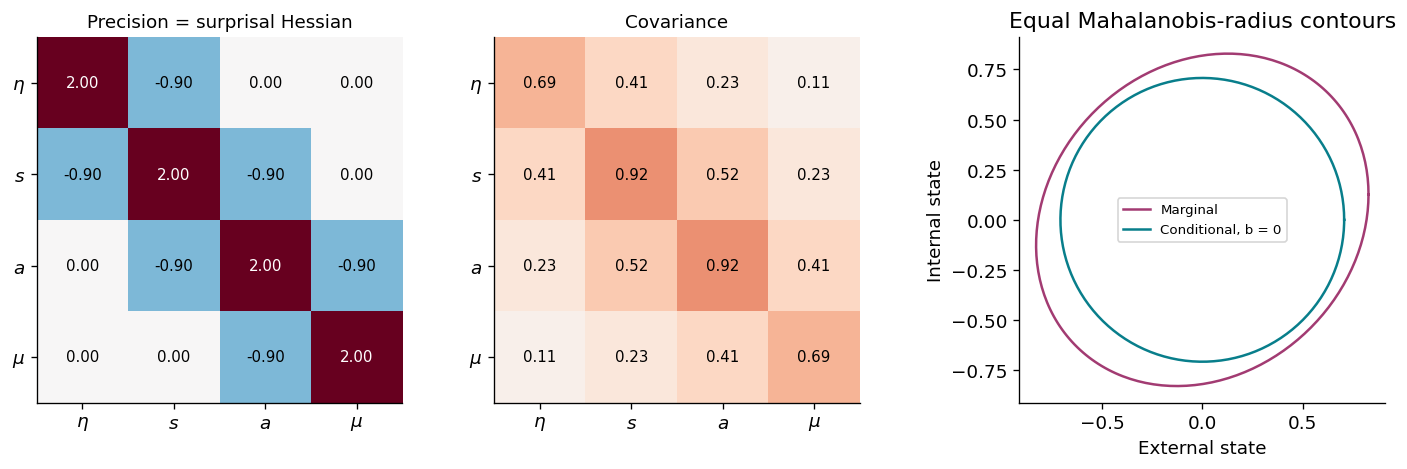

In [2]:
#| label: fig-eq11-screening
#| fig-cap: "The precision has the required zeros, although the covariance connects distant variables. Fixing the blanket removes the external–internal conditional correlation."
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, matrix, title in zip(axes[:2], [K, Sigma], ["Precision = surprisal Hessian", "Covariance"]):
    im = ax.imshow(matrix, cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_xticks(range(4), labels); ax.set_yticks(range(4), labels)
    ax.set_title(title, fontsize=11)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center",
                    color="white" if abs(matrix[i,j]) > 1.3 else "black", fontsize=9)
# Draw analytic covariance ellipses, not regression-based approximations.
angle = np.linspace(0, 2*np.pi, 250)
circle = np.vstack([np.cos(angle), np.sin(angle)])
for cov, color, label in [(Suu,"#a23b72","Marginal"),
                          (conditional_cov,"#087e8b","Conditional, b = 0")]:
    ellipse = np.linalg.cholesky(cov) @ circle
    axes[2].plot(*ellipse, color=color, label=label)
axes[2].set(xlabel="External state", ylabel="Internal state", title="Equal Mahalanobis-radius contours")
axes[2].set_aspect("equal"); axes[2].legend(fontsize=8)
plt.show()

The compatible diffusion in the code deliberately takes $Q=0$ and constant diagonal noise, so $J=-\Gamma H$. The implication from zero $J$ to zero $H$ is transparent in this restricted example. It is a valid special case, not a simulation of a complete biological perception–action system.

### A counterexample if we drop the special sparse-coupling assumptions

Consider two variables with drift $f(x)=Ax$,

$$A=\begin{bmatrix}-1&0\\1&-1\end{bmatrix},\qquad\Gamma=I.$$

There is no direct influence of variable 2 on the drift of variable 1: $A_{12}=0$. Nevertheless, variable 1 drives variable 2, producing a correlated stationary density. The stationary covariance solves

$$A\Sigma+\Sigma A^{\mathsf T}+2I=0.$$

The next cell checks that its precision has $H_{12}\neq0$, and exhibits the cancellation excluded by the paper's special definition.

In [3]:
#| label: eq11-counterexample
A = np.array([[-1., 0.], [1., -1.]])
Sigma_c = solve_continuous_lyapunov(A, -2*np.eye(2))
H_c = np.linalg.inv(Sigma_c)
Q_c = A @ Sigma_c + np.eye(2)
Omega_c = Q_c - np.eye(2)
assert np.allclose(Q_c, -Q_c.T)
assert np.allclose(Omega_c @ H_c, A)
assert A[0,1] == 0 and abs(H_c[0,1]) > 0.1
terms = Omega_c[0,:]*H_c[:,1]
assert abs(terms.sum()) < 1e-12 and np.all(np.abs(terms)>0.1)
print("Stationary covariance:\n", Sigma_c)
print("Steady-state Hessian (precision):\n", H_c)
print("Contributions to J_12 = sum_i Omega_1i H_i2:", terms)
print("They cancel, giving J_12 = 0 despite H_12 != 0.")

Stationary covariance:
 [[1.  0.5]
 [0.5 1.5]]
Steady-state Hessian (precision):
 [[ 1.2 -0.4]
 [-0.4  0.8]]
Contributions to J_12 = sum_i Omega_1i H_i2: [ 0.4 -0.4]
They cancel, giving J_12 = 0 despite H_12 != 0.


This does not contradict Equation (11) as qualified by Equations (9)–(10): the example violates the no-cancellation restriction. It shows precisely why the qualification is needed.

## 14. The conceptual chain from Equation (6) to Equation (11)

| Step | Mathematical statement | Question answered |
|---|---|---|
| Equation (6) | $f=\Omega\nabla\Im-\Lambda$ | How is drift related to a steady-state probability landscape? |
| Equation (8) | $J=\Omega H+\nabla\Omega\cdot\nabla\Im-\nabla\Lambda$ | How are dynamical sensitivities related to mixed curvature? |
| Equations (9)–(10) | Relevant terms vanish individually | Which restrictions make missing influences imply zero curvature? |
| Equation (7) | $H_{uv}=0\Leftrightarrow x_u\perp x_v\mid\text{others}$ | How does curvature encode screening? |
| Equation (11) | Apply this to the three pairs | Which independencies support the particular partition? |

**Clark connection — FEP is broader than predictive processing.** In Section 2 and footnotes 6–9, Clark distinguishes describing an adaptive system as a self-evidencing model from claiming that it implements online top-down prediction-error minimization. That distinction belongs here: none of the derivatives in Equation (11) establishes a predictive-coding algorithm. Later FEP constructions may support an inference interpretation under further assumptions, but this equation alone provides a partition and statistical constraints.

## 15. Why this matters for the idea of a “thing”

The mathematical strategy begins with variables and relations rather than presupposing a membrane, skull, or organism. A blanket gives a statistical way to distinguish an internal set from a remaining external set. That is useful for studying how an organized system relates to its surroundings.

There is a subtlety specific to this paper. Section 4 constructs **active states as a Markov boundary of internal states**, then **sensory states as a Markov boundary of autonomous states** $\alpha=(a,\mu)$. Their union $b=(s,a)$ is called the blanket. Consequently, $b$ should not automatically be called the *minimal* boundary of $\mu$. In our Gaussian chain, $a$ alone screens $\mu$ from $(\eta,s)$, while $(s,a)$ also screens it from $\eta$. This is a concrete example of the blanket/boundary distinction Clark makes in Section 1.

### Multiple blankets, without arbitrary boundaries

Clark's Section 1 discusses nested organizations; Sections 5–6 develop the argument that biological and cognitive boundaries can be multiple and malleable. Different internal sets, scales, or explanatory questions can identify different useful screening relations. This should not be read as proving multiple minimal boundaries for one fixed target in one fixed positive distribution, nor that adding arbitrary variables always preserves screening.

Our tridiagonal Gaussian gives a small exact illustration: $a$ is a boundary for $\mu$, while $s$ screens the pair $(a,\mu)$ from $\eta$. The nested statistical partition is demonstrable. Identifying the corresponding variables in a real organism is a separate empirical task.

### Metamorphosis and a process view of identity

In Section 5 Clark uses the caterpillar–pupa–butterfly lifecycle to argue that persistence need not require one unchanging morphology. Section 6 develops a process-based account: learning and development can reorganize the resources through which an agent senses, acts, and maintains itself.

This is a productive interpretation of the mathematics, but Equation (11) concerns a specified partition and the paper's steady-state description. It does **not** itself prove that the same density and exact independence relations remain valid throughout metamorphosis. Modeling such change requires an expanded state description, a justified separation of timescales, or a time-dependent model with its assumptions checked anew.

Clark's central philosophical proposal is therefore compatible with, but not entailed by, our derivation: boundaries can matter without one particular anatomical boundary settling every question about cognition.

### A question to carry into the rest of the book

When someone proposes a Markov blanket, ask: **Which variables, which internal target, which conditioning set, which probability distribution, and which timescale?** Those choices make the claim testable and keep the mathematical screening relation connected to the explanatory purpose.

## Check your understanding

1. What influence does $J_{s\mu}$ measure?
2. Does $H_{\mu\eta}(x_*)=0$ at one point prove independence?
3. Can $\Sigma_{\mu\eta}\neq0$ coexist with $H_{\mu\eta}=0$ for a Gaussian?
4. What extra premise prevents the two-variable counterexample from invalidating the paper's qualified implication?
5. Does knowing a blanket determine an internal state exactly?
6. Does Clark's argument prove that a particular smartphone lies inside an exact Markov blanket?

### Answers

1. The sensitivity of sensory drift to internal states: the second index influences the first.
2. No. We need the mixed block to vanish over the relevant domain and suitable density/support conditions.
3. Yes. Marginal correlation and conditional dependence are different. Precision zeros encode Gaussian conditional independence given the other variables.
4. The paper imposes termwise vanishing, excluding cancellation of nonzero contributions and constraining the solenoidal terms.
5. No. It specifies a conditional distribution; uncertainty and intrinsic dynamics remain. See Clark, footnote 2.
6. No. Clark argues that cognition need not have a uniquely fixed biological boundary. A proposed extended system still requires a defensible model and evidence for its statistical and functional organization.

The sentence to remember is: **Under the paper's special sparse-coupling assumptions, absent direct influences imply zero mixed curvature of steady-state surprisal; those zeros express the conditional independencies defining the partition.**

## Sources and Quarto setup

**Mathematical source:** Friston, K., Da Costa, L., Sajid, N., Heins, C., Ueltzhöffer, K., Pavliotis, G. A., and Parr, T. (2023). *The free energy principle made simpler but not too simple*. Physics Reports, 1024, 1–29. [DOI](https://doi.org/10.1016/j.physrep.2023.07.001). Section 4, Equations (7)–(13), especially the definition in (9), footnote 10, and the partition construction preceding (11). Checked against the uploaded PDF.

**Conceptual source:** Clark, A. (2017). *How to Knit Your Own Markov Blanket: Resisting the Second Law with Metamorphic Minds*. Uploaded EPUB, authored content `OEBPS/03_Clark.xhtml`. Citations in this notebook use its numbered sections and footnotes because EPUB page numbers vary by reader. Relevant locations: Section 1 and footnote 2 (screening, prediction, blanket/boundary); Section 2 and footnotes 6–9 (FEP versus predictive processing); Sections 3–4 (embodiment and extension); Sections 5–6 (metamorphosis, malleability, process); Section 8 (conclusion). Clark's views are paraphrased and attributed; no chapter text or illustrations are reproduced.

**Teaching source:** the supplied `Pasted markdown(5).md`. This notebook retains its explanatory sequence while adding the converse proof, numerical illustrations, source connections, and qualifications on sparse coupling and support. Clark's discussion predates the 2023 paper; the connections drawn here are pedagogical comparisons, not claims that Clark comments on Equation (11).

Save this notebook as `chapters/equation-11-markov-blankets.ipynb` in your book. Add this entry to your existing `book.chapters` list in `_quarto.yml`:

```yaml
- chapters/equation-11-markov-blankets.ipynb
```

The raw first cell contains Quarto metadata. All computations are self-contained and outputs are embedded. To recompute, install `numpy scipy matplotlib` in your Jupyter environment and run the code cells in order, then save. From the book root, use `quarto preview`, or explicitly recompute with:

```bash
quarto render chapters/equation-11-markov-blankets.ipynb --execute
```

See [Quarto's JupyterLab guide](https://quarto.org/docs/tools/jupyter-lab.html). The source EPUB and PDF are cited reading materials and are not runtime dependencies.